## Locally Stationary Processes

A **locally stationary process (LSP)** in Silverman’s sense is defined by a covariance function that can be written as the product of two factors:

$$
C(s,t) = q\!\left(\tfrac{s+t}{2}\right) \cdot r(s-t) = q(\eta)\,r(\tau)
$$

- $r(\tau)$: a stationary covariance function normalized such that $r(0)=1$.  
- $q(\eta)$: a non-negative function describing the **time-varying instantaneous power**.  

When $q(\eta)$ is constant, this reduces to an ordinary stationary covariance, so stationary processes are a special case of LSPs.

This formulation offers great flexibility: different choices of $r(\tau)$ and $q(\eta)$ can model a wide variety of time-varying signals, provided the resulting covariance is **non-negative definite**.

---

### Example

Let's simulate realizations from an LSP model with covariance defined by a Gaussian-shaped $q(\eta)$ and exponential $r(\tau)$: 
$$
q_{\lambda}(\eta) = L + a_q \cdot \exp\!\left(-c_q \frac{(\eta - b_q)^2}{2}\right),
$$
$$
r_{\rho}(\tau) = \exp\!\left(-\frac{c_r \tau^2}{8}\right)
$$
Three parameter sets $(L, a_q, b_q, c_q, c_r )$ are compared:

- **Case (a)** $(150, 800, 0.25, 250, 3000)$  
- **Case (b)** $(0, 500, 0.25, 1000, 80000)$  
- **Case (c)** $(100, 500, 0.25, 1000, 80000)$  

Although all cases have maximum energy around the midpoint of the time interval ($t=0.25$), the interaction between $q(\eta)$ and $r(\tau)$ leads to different behaviors:

- Case (a): **slowly varying** realizations.  
- Case (b): **faster variations** with very low baseline noise ($L=0$).  
- Case (c): similar to (b) but with more noise due to higher baseline energy level ($L=100$).  

The parameter $L$ therefore controls the **minimum average energy level**, potentially modeling additive noise in the time-varying signal.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lsp_sim.lsp_f0_sim import lsp_f0_sim

def simulate_case(params, N=256, T0=0.0, Tf=0.5, num_real=10, seed=50):
    """params = (L, a_q, b_q, c_q, c_r)"""
    L, a_q, b_q, c_q, c_r = params
    np.random.seed(seed)
    time_vec = T0 + np.arange(N) * (abs(Tf - T0) / (N - 1))

    X, X_freq, C, C_freq, R, R_freq, Q = lsp_f0_sim(
        num_sim=num_real,
        f0=0.0,                 # centre frequency fixed at 0
        a_q=a_q,
        b_q=b_q,
        c_q=c_q,
        c_r=c_r,
        L=L,
        N=N,
        time=time_vec
    )
    return time_vec, X, C

# ----- Cases -----
cases = {
    "Case (a)": (150, 800, 0.25, 250, 3000),
    "Case (b)": (0, 500, 0.25, 1000, 80000),
    "Case (c)": (100, 500, 0.25, 1000, 80000),
}

results = {name: simulate_case(params) for name, params in cases.items()}


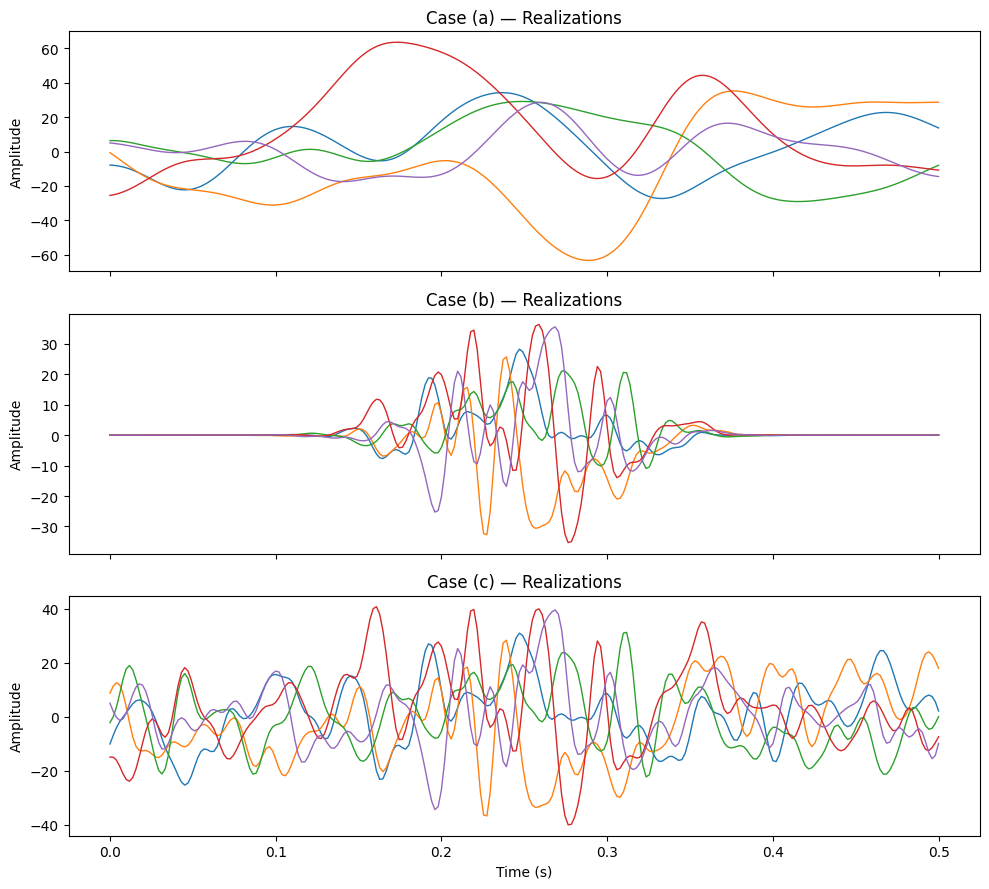

In [2]:
# ----- Figure 1: Realizations  -----
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 9), sharex=True)
for ax, (name, (time_vec, X, _)) in zip(axes, results.items()):
    for i in range(min(5, X.shape[1])):  # plot up to 5 realizations
        ax.plot(time_vec, X[:, i], lw=1)
    ax.set_title(f"{name} — Realizations")
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


Let's also plot the covariance matrix for each case:

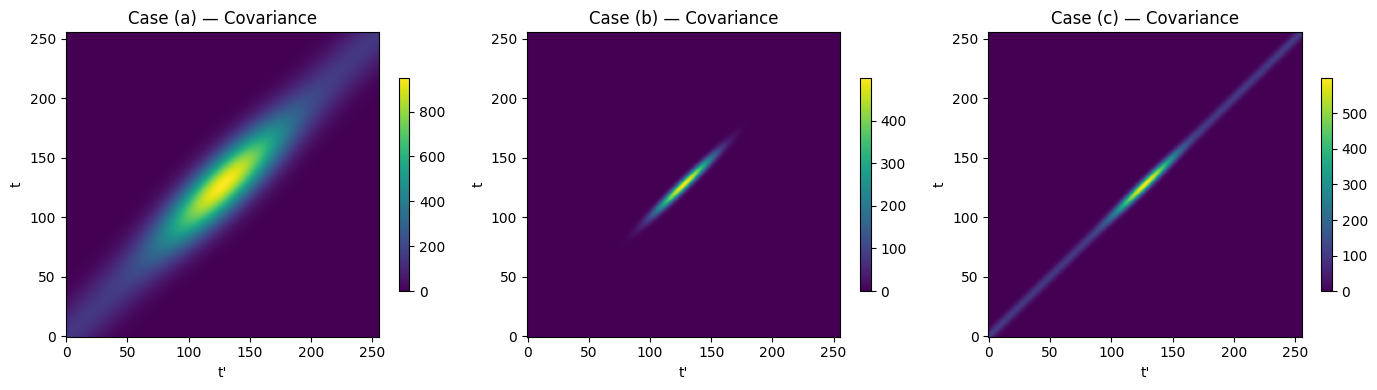

In [3]:
# ----- Figure 2: Covariance matrices -----
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 4))
for ax, (name, (_, _, C)) in zip(axes, results.items()):
    im = ax.imshow(C, origin='lower', aspect='auto')
    ax.set_title(f"{name} — Covariance")
    ax.set_xlabel("t'")
    ax.set_ylabel("t")
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

Let's plot the Wigner-Ville distribution (WVD) for each case. Note that we will shift to a center frequency $f_0$ for visualization purposes, since the WVD is time- and frequency- invariant. 

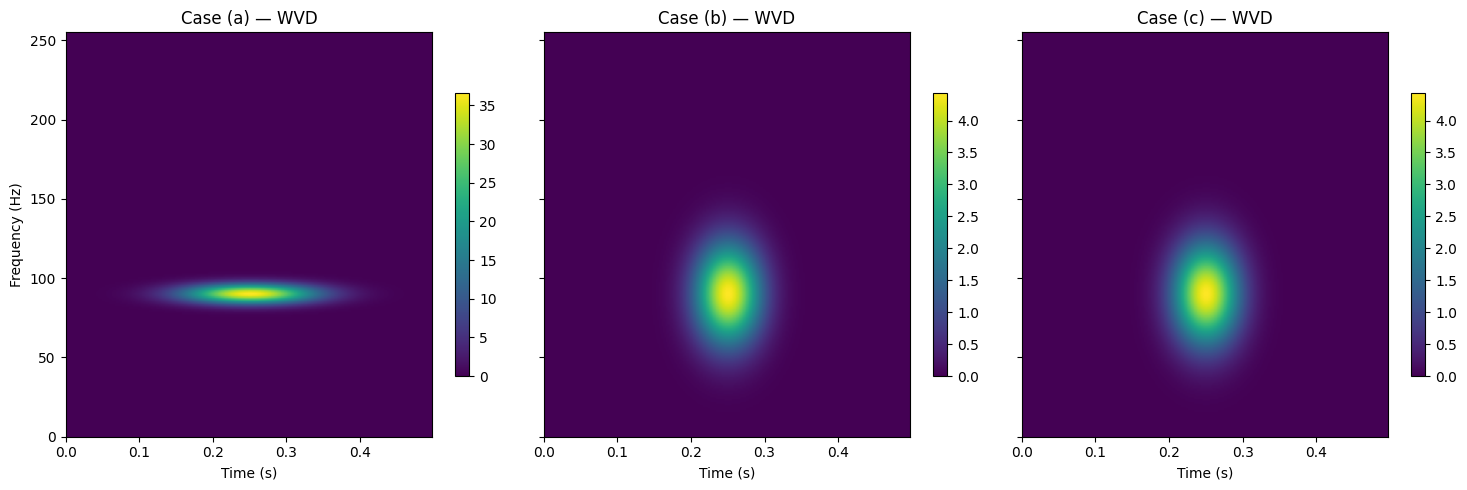

In [4]:
from lsp_sim.wv_lsp import wvshifted_lsp

# Common parameters
noise = 0
dataN = 256
T0, Tf = 0, 0.5
delta_t = abs(Tf - T0) / (dataN - 1)
time_vec = T0 + np.arange(dataN) * delta_t

fs = 512
f0 = 90   # Hz
nfft = 512

# Compute WVD for each case
wv_results = {}
for name, (L, a_q, b_q, c_q, c_r) in cases.items():
    WVshift, TI, FI, WV0 = wvshifted_lsp(noise, a_q, b_q, c_q, c_r, dataN, f0, fs, nfft)
    wv_results[name] = (WVshift, TI, FI)

# Plot the three WVDs side by side
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharey=True)
for ax, (name, (WVshift, TI, FI)) in zip(axes, wv_results.items()):
    im = ax.imshow(np.abs(WVshift).T, aspect='auto',
                   extent=[TI[0], TI[-1], FI[0], FI[-1]],
                   origin='lower')
    ax.set_title(f"{name} — WVD")
    ax.set_xlabel("Time (s)")
    if ax is axes[0]:
        ax.set_ylabel("Frequency (Hz)")
    fig.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()
